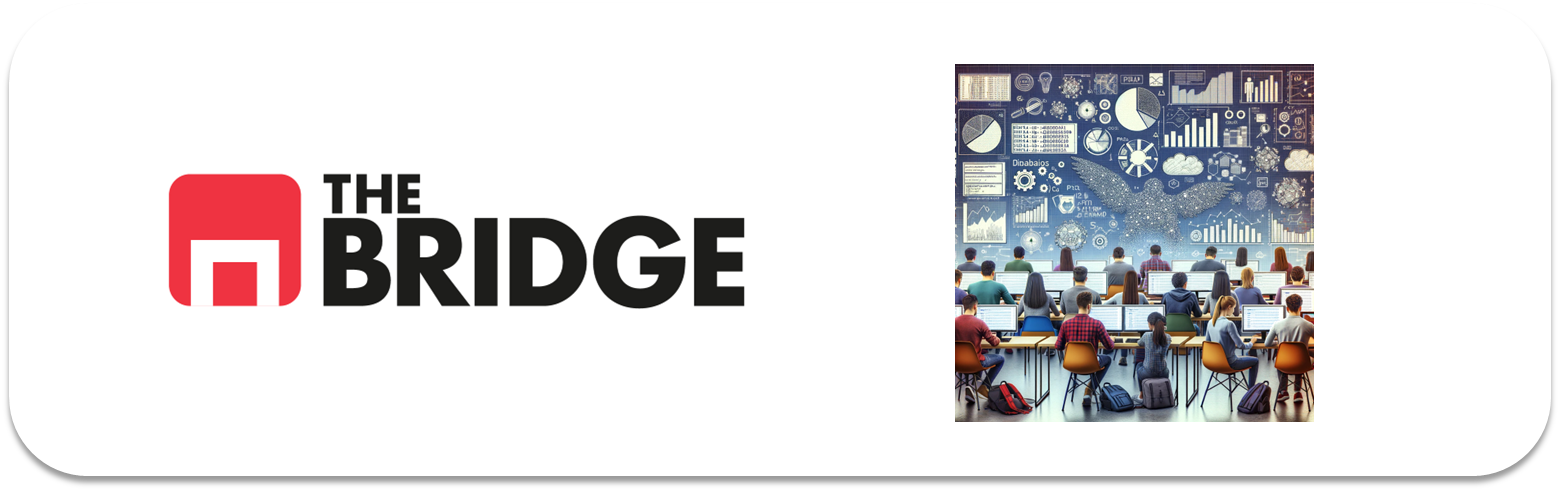

## PRACTICA OBLIGATORIA: **Regresion Lineal y Regularización**

* La práctica obligatoria de esta unidad consiste en hacer un modelado completo de un problema que ya conoces, la predicción de casas, pero con otro dataset. Descarga este notebook en tu ordenador y trabaja en local. Ten en cuenta que tendrás que descar los directorios de imágenes y datos adicionales, si los hubiera.
* Recuerda que debes subirla a tu repositorio personal antes de la sesión en vivo para que puntúe adecuadamente.  
* Recuerda también que no es necesario que esté perfecta, sólo es necesario que se vea el esfuerzo. 
* Esta práctica se resolverá en la sesión en vivo correspondiente y la solución se publicará en el repo del curso. 

### Modelo de Regresión Lineal

El objetivo del modelo que tienes que construir es predecir la mediana del precio de las casas en una zona del área metropolitana de Boston dadas las características de las mismas. Sí, es parecido pero no igual a lo que hemos venido haciendo.

Aquí tienes una descripción de las variables del dataset, del que tendrás que decidir el target:  

***CRIM:*** Tasa de criminalidad per cápita por ciudad  
***ZN:*** Proporción de terreno residencial destinado a lotes de más de 25,000 pies cuadrados  
***INDUS:*** Proporción de acres de negocios no minoristas por ciudad  
***CHAS:*** Variable ficticia del río Charles (= 1 si el sector limita con el río; 0 en caso contrario)  
***NOX:*** Concentración de óxidos de nitrógeno (partes por 10 millones)  
***RM:*** Número promedio de habitaciones por vivienda  
***AGE:*** Proporción de unidades ocupadas por el propietario construidas antes de 1940  
***DIS:*** Distancias ponderadas a cinco centros de empleo de Boston  
***RAD:*** Índice de accesibilidad a autopistas radiales  
***TAX:*** Tasa de impuesto sobre la propiedad de valor total por $10,000  
***PTRATIO:*** Relación alumno-maestro por ciudad  
***LSTAT:*** % de población de estatus socioeconómico bajo  
***MEDV:*** Valor medio de las viviendas ocupadas por sus propietarios en miles de dólares  

### Indicaciones

A continuación tienes las indicaciones para hacer el modelado. No necesariamente tienes que seguirlos al pie de la letra, porque a partir de ahora ya las práctica obligatorias dejarán de ser mayormente guiadas por ejercicios y serán más de libre desarrollo, aunque con objetivos específicos, claros y determinados. 

En concreto se pide hacer un modelo de regresión lineal, evaluarlo contra un dataset de test reservado del original mostrando MAE,RMSE,MSE y $R2$, comparar las predicciones con los valores reales y realizar al menos un tipo de regularización de las conocidas, testando por lo menos 3 valores diferentes de hiperparámetros.

Los pasos para guiar el trabajo:
1. Carga el dataset. Está limpio y no necesitarás completar nulos, ni repasar los valores de las columnas.
2. Escoge y analiza la variable target de forma gráfica para ver la idoneidad de hacer un modelo de regresión.
3. Haz el split en train y test que creas conveniente y de la forma que creas conveniente.
4. Construye las parejas X,y de train y test
5. Haz un mini-EDA, selecciona las features que quieres quedarte y por qué.
6. Trata las variables para que funcionen lo mejor posible en el modelo.
7. Construye un modelo de regresión lineal.
8. Analiza si lo crees conveniente los pesos y la importancia de las features.
8. Evalúa tu modelo. Haz un pequeño assesmente de su generabilidad. Compara gráficamente las predicciones con los valores reales.
9. Regulariza al menos con un modelo alternativo y juega con 3 posibles valores de los hiperparámetros del modelo de regularización.
10. Expresa tus conclusiones, en concreto ¿con qué modelo te quedarías?¿por qué?



In [67]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style('whitegrid')

In [68]:
df = pd.read_csv("./data/hard_to_find/obligatoria_hard.csv",delimiter="|")

In [69]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 506 entries, 0 to 505
Data columns (total 13 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   CRIM     506 non-null    float64
 1   ZN       506 non-null    float64
 2   INDUS    506 non-null    float64
 3   CHAS     506 non-null    float64
 4   NOX      506 non-null    float64
 5   RM       506 non-null    float64
 6   AGE      506 non-null    float64
 7   DIS      506 non-null    float64
 8   RAD      506 non-null    float64
 9   TAX      506 non-null    float64
 10  PTRATIO  506 non-null    float64
 11  LSTAT    506 non-null    float64
 12  MEDV     506 non-null    float64
dtypes: float64(13)
memory usage: 51.5 KB


<Axes: xlabel='MEDV', ylabel='Count'>

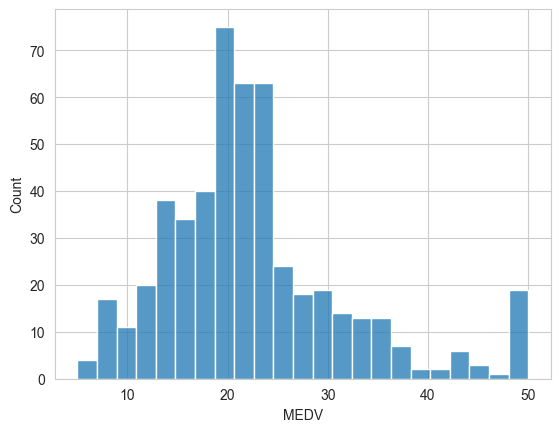

In [70]:
target = "MEDV"
sns.histplot(df[target])

In [71]:
from sklearn.model_selection import train_test_split

In [72]:
x= df.drop("MEDV",axis=1)
y=df["MEDV"]

In [73]:
x_train,x_test,y_train,y_test = train_test_split(x,y, train_size = 0.8)

In [74]:
df.corr()["MEDV"]

CRIM      -0.388305
ZN         0.360445
INDUS     -0.483725
CHAS       0.175260
NOX       -0.427321
RM         0.695360
AGE       -0.376955
DIS        0.249929
RAD       -0.381626
TAX       -0.468536
PTRATIO   -0.507787
LSTAT     -0.737663
MEDV       1.000000
Name: MEDV, dtype: float64

In [75]:
df.describe()

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,LSTAT,MEDV
count,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000
mean,3.613524,11.363636,11.136779,0.069170,0.554695,6.284634,68.574901,3.795043,9.549407,408.237154,18.455534,12.653063,22.532806
std,8.601545,23.322453,6.860353,0.253994,0.115878,0.702617,28.148861,2.105710,8.707259,168.537116,2.164946,7.141062,9.197104
min,0.006320,0.000000,0.460000,0.000000,0.385000,3.561000,2.900000,1.129600,1.000000,187.000000,12.600000,1.730000,5.000000
25%,0.082045,0.000000,5.190000,0.000000,0.449000,5.885500,45.025000,2.100175,4.000000,279.000000,17.400000,6.950000,17.025000
50%,0.256510,0.000000,9.690000,0.000000,0.538000,6.208500,77.500000,3.207450,5.000000,330.000000,19.050000,11.360000,21.200000
75%,3.677083,12.500000,18.100000,0.000000,0.624000,6.623500,94.075000,5.188425,24.000000,666.000000,20.200000,16.955000,25.000000
max,88.976200,100.000000,27.740000,1.000000,0.871000,8.780000,100.000000,12.126500,24.000000,711.000000,22.000000,37.970000,50.000000


<Axes: >

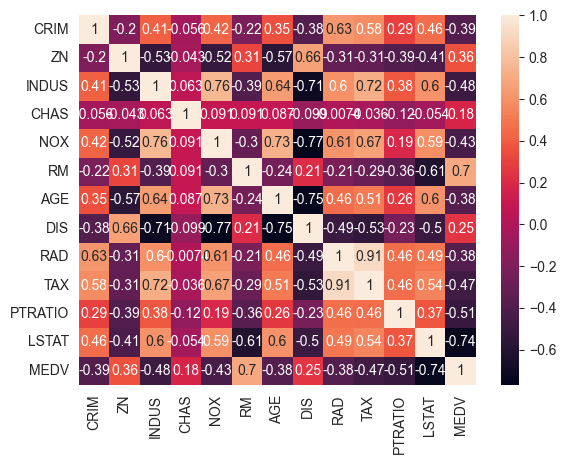

In [76]:
sns.heatmap(df.corr(),annot=True)

In [77]:
x_train.columns

Index(['CRIM', 'ZN', 'INDUS', 'CHAS', 'NOX', 'RM', 'AGE', 'DIS', 'RAD', 'TAX',
       'PTRATIO', 'LSTAT'],
      dtype='object')

<Axes: >

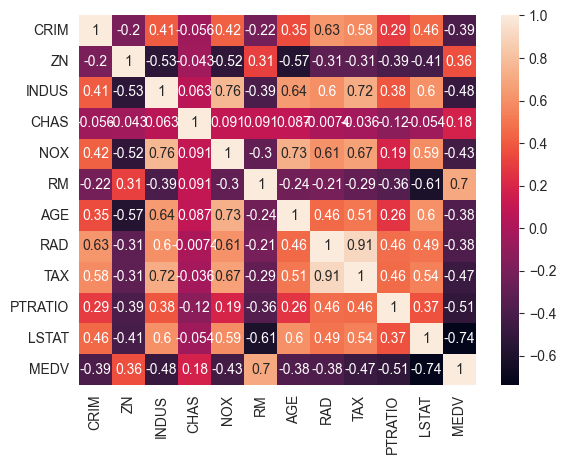

In [78]:
# voy a eliminar diss, porque correlaciona demasiado con otras variables, menos con MEDV que correlaciona muy poco
features=['CRIM', 'ZN', 'INDUS', 'CHAS', 'NOX', 'RM', 'AGE', 'RAD', 'TAX',
       'PTRATIO', 'LSTAT',"MEDV" ]
sns.heatmap(df[features].corr(),annot=True)

<Axes: >

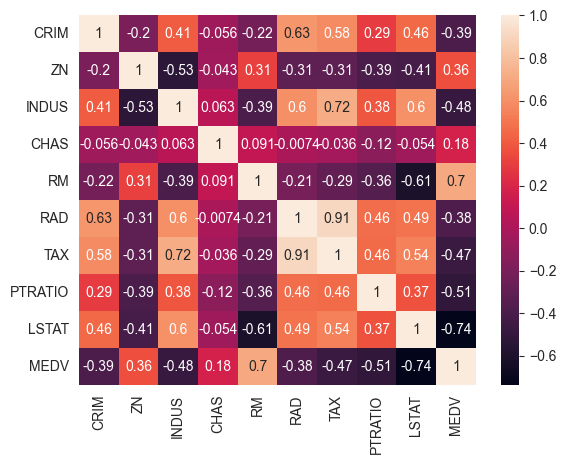

In [79]:
# NOS INDUS Y AGE, CORRELACIONAN A MAS DEL 0,7 ME QUEDO CON UNA SOLA, EN ESTE CASO INDUS CORRELACIONA MAS
features=['CRIM', 'ZN', 'INDUS', 'CHAS', 'RM', 'RAD', 'TAX',
       'PTRATIO', 'LSTAT',"MEDV" ]
sns.heatmap(df[features].corr(),annot=True)

<Axes: >

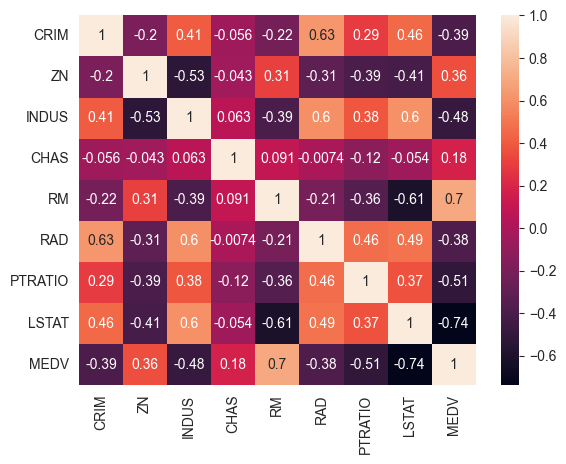

In [80]:
# LAS DOS QUE MÁS LLAMAN LA ATENCIÓN AHORA CON RAD Y TAX, PESE A QUE TAX CORRELACIONA MEJOR CON LA VARIBLE, TAMBIÉN CORRELACIONA MAS CON EL RESTO DE FEATURES, ME QUEDO CON RAD
features=['CRIM', 'ZN', 'INDUS', 'CHAS', 'RM',  'RAD',
       'PTRATIO', 'LSTAT',"MEDV" ]
sns.heatmap(df[features].corr(),annot=True)

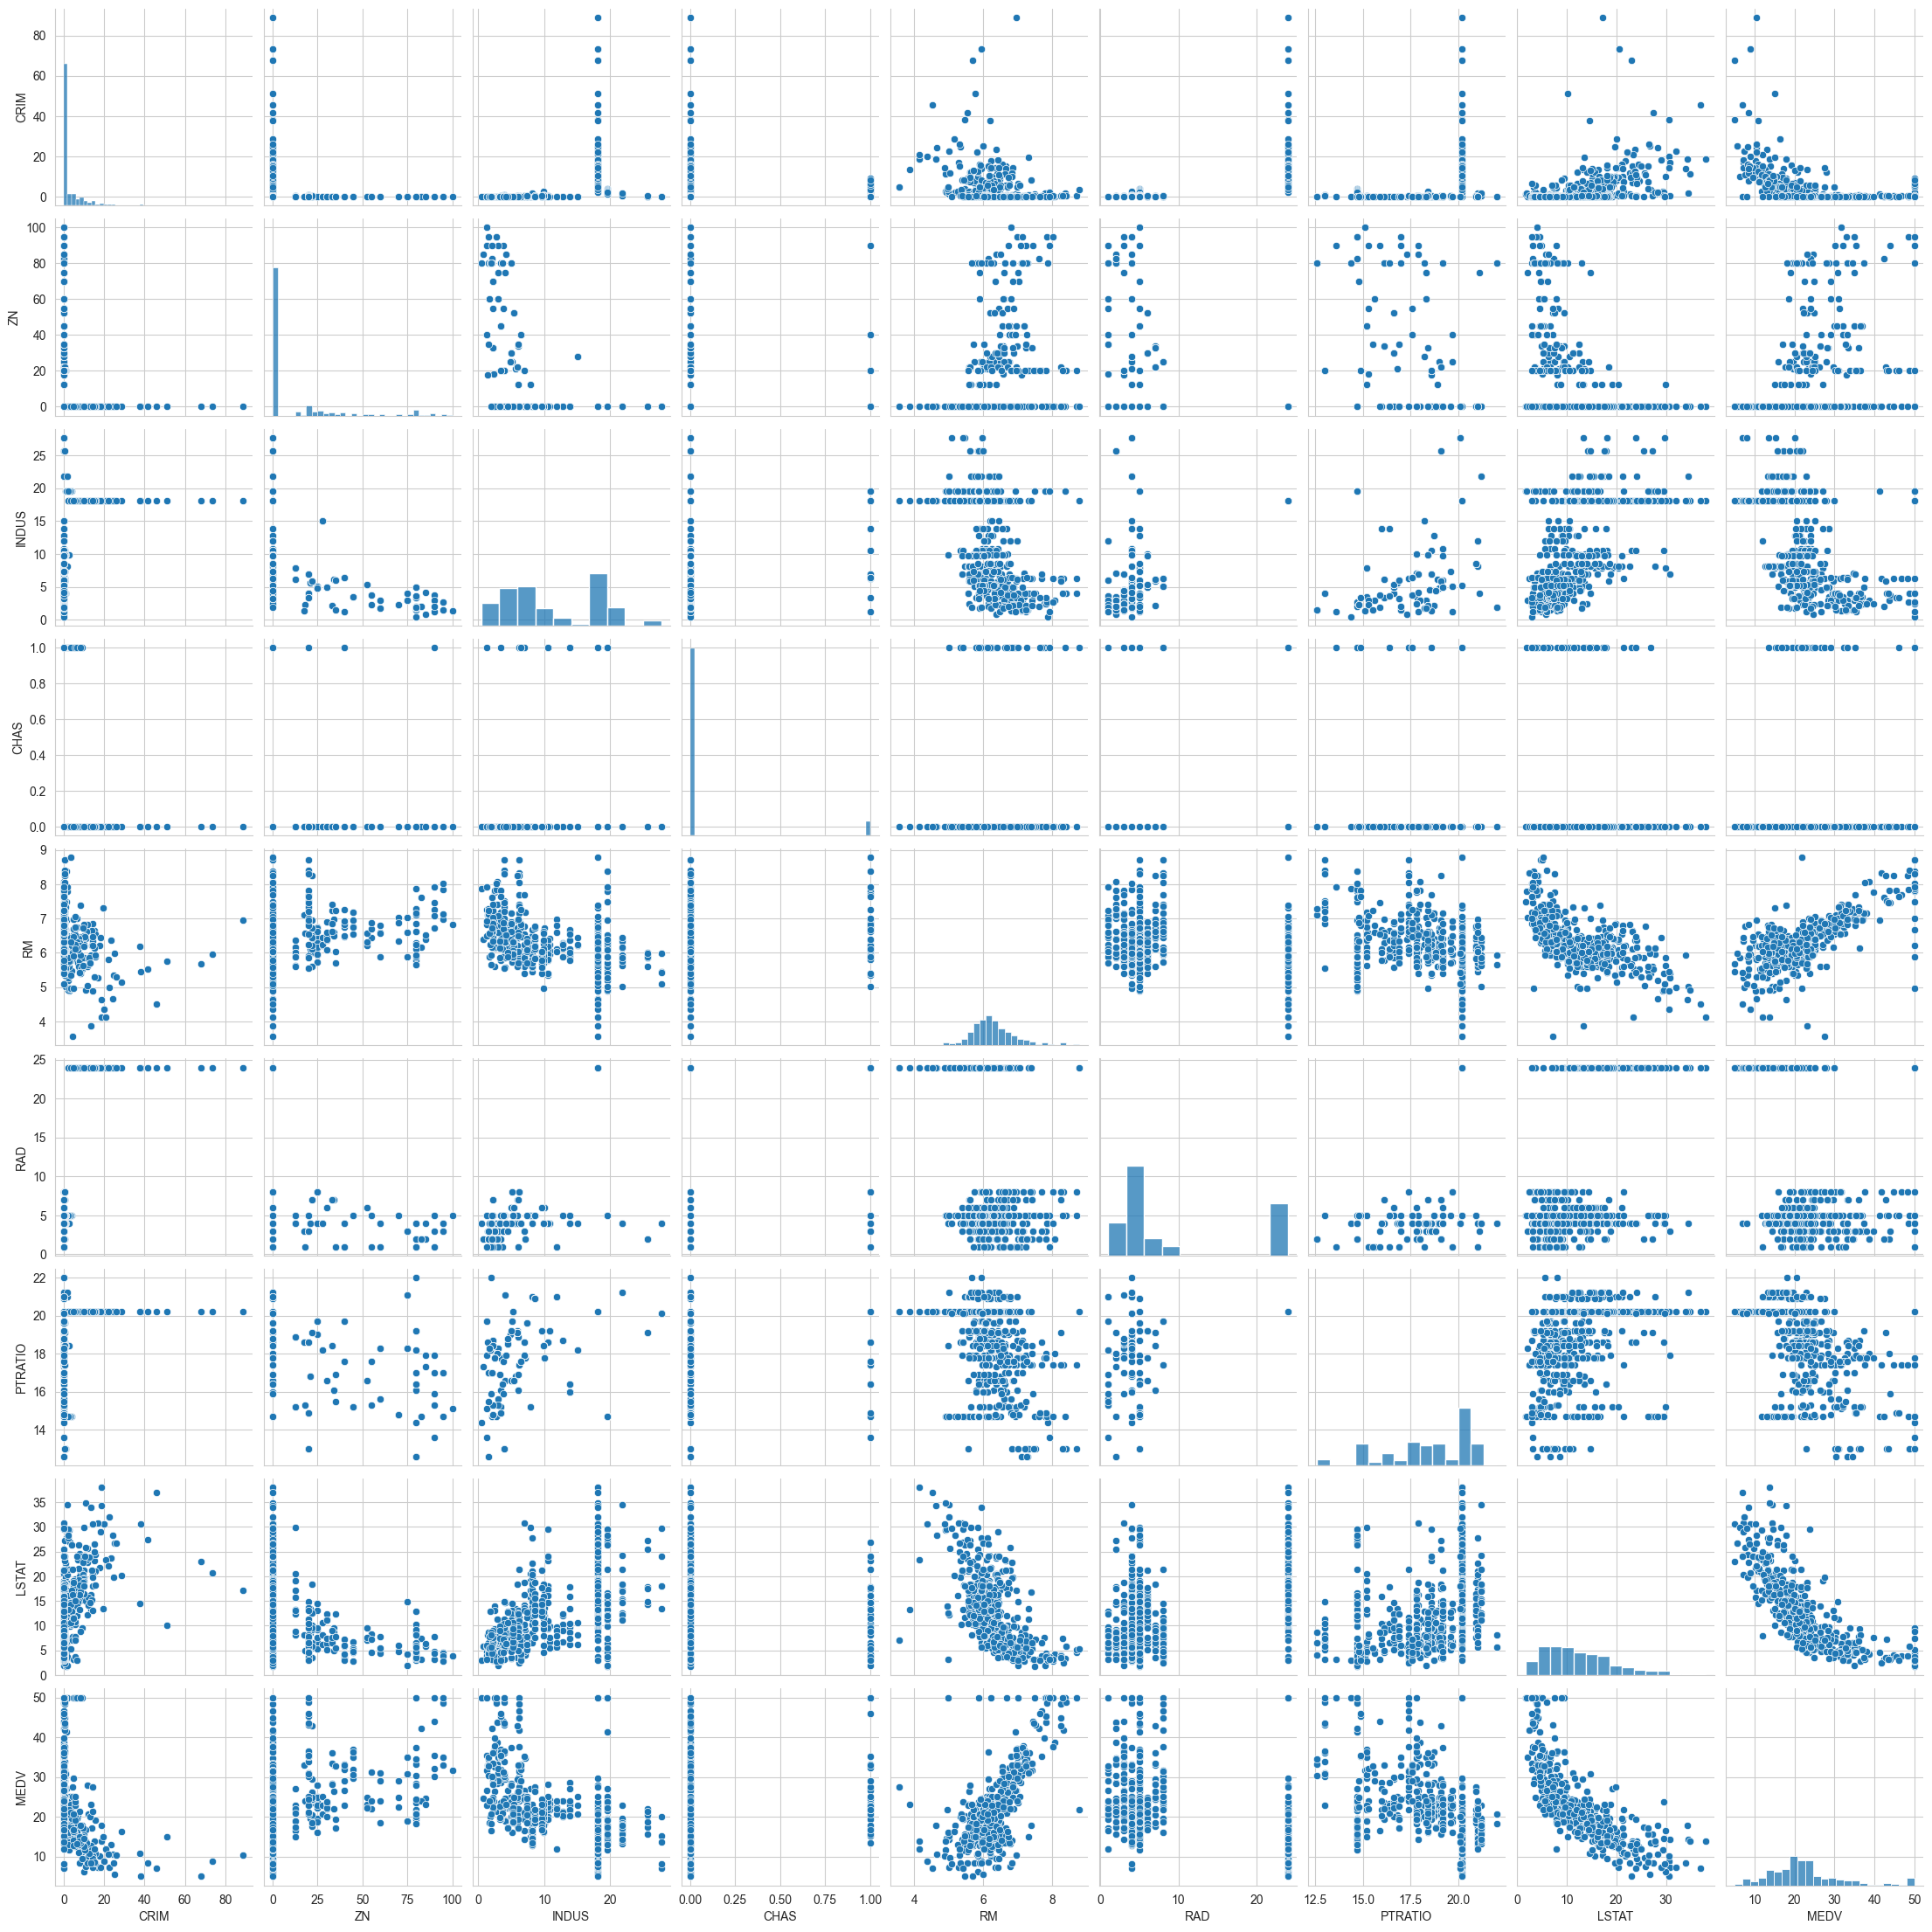

In [81]:
sns.pairplot(df[features]);

In [82]:
features=['CRIM', 'ZN', 'INDUS', 'CHAS', 'RM',  'RAD',
       'PTRATIO', 'LSTAT']

In [83]:
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()
x_train_scaled = pd.DataFrame(scaler.fit_transform(x_train[features]), columns= features, index=x_train.index)
x_test_scaled = pd.DataFrame(scaler.transform(x_test[features]), columns= features, index=x_test.index)

In [84]:
x_train_scaled.describe()

,CRIM,ZN,INDUS,CHAS,RM,RAD,PTRATIO,LSTAT
count,4.040000e+02,4.040000e+02,4.040000e+02,4.040000e+02,4.040000e+02,4.040000e+02,4.040000e+02,4.040000e+02
mean,1.319077e-17,4.396923e-18,2.440292e-16,2.198461e-18,-1.525732e-15,5.056461e-17,3.429600e-16,1.275108e-16
std,1.001240e+00,1.001240e+00,1.001240e+00,1.001240e+00,1.001240e+00,1.001240e+00,1.001240e+00,1.001240e+00
min,-4.181388e-01,-5.074262e-01,-1.504906e+00,-2.780887e-01,-3.836400e+00,-9.859624e-01,-2.752830e+00,-1.480588e+00
25%,-4.093584e-01,-5.074262e-01,-8.685775e-01,-2.780887e-01,-5.668681e-01,-6.429697e-01,-5.163358e-01,-8.041773e-01
50%,-3.897807e-01,-5.074262e-01,-3.714008e-01,-2.780887e-01,-1.123372e-01,-5.286389e-01,2.757558e-01,-1.958198e-01
75%,4.575804e-03,3.615869e-01,1.011417e+00,-2.780887e-01,4.784827e-01,1.643648e+00,7.882857e-01,6.105115e-01
max,9.780185e+00,3.837639e+00,2.408730e+00,3.595975e+00,3.496512e+00,1.643648e+00,1.626971e+00,3.339527e+00


In [85]:
from sklearn.linear_model import LinearRegression

In [86]:
ln = LinearRegression()
ln.fit(x_train_scaled,y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [87]:
coef_df = pd.DataFrame(ln.coef_).T
coef_df.columns= features

In [88]:
coef_df["intercept"]=ln.intercept_

<Axes: >

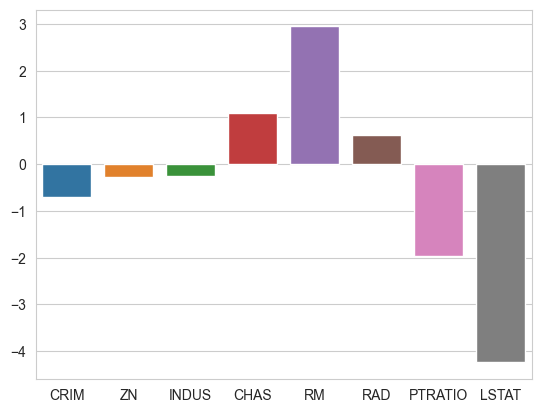

In [89]:
sns.barplot(coef_df[features])

In [90]:
# se aprecia claramente que zn es irrelevante, convendría eliminarlo

In [91]:
features=['CRIM', 'INDUS', 'CHAS', 'RM',  'RAD',
       'PTRATIO', 'LSTAT']

<Axes: >

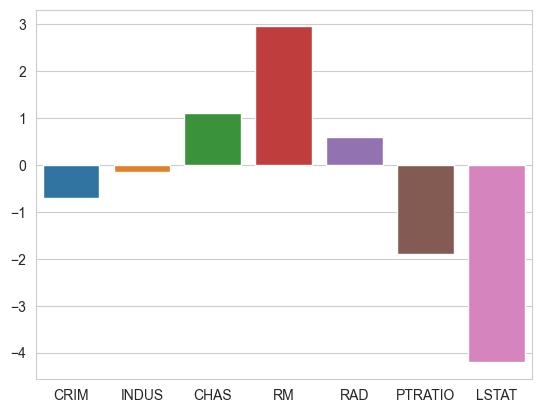

In [92]:
x_train_scaled = pd.DataFrame(scaler.fit_transform(x_train[features]), columns= features, index=x_train.index)
x_test_scaled = pd.DataFrame(scaler.transform(x_test[features]), columns= features, index=x_test.index)
ln.fit(x_train_scaled,y_train)
coef_df = pd.DataFrame(ln.coef_).T
coef_df.columns= features
coef_df["intercept"]=ln.intercept_
sns.barplot(coef_df[features])

In [93]:
from sklearn import metrics

In [94]:
pred_train = ln.predict(x_train_scaled)
pred_test = ln.predict(x_test_scaled)

In [95]:
print('MAE train', metrics.mean_absolute_error(y_train, pred_train))
print('MSE train', metrics.mean_squared_error(y_train, pred_train))
print('RMSE train', np.sqrt(metrics.mean_squared_error(y_train, pred_train)))
print('R2 train', ln.score(x_train_scaled,y_train))

MAE train 3.4625777191345084
MSE train 23.7570332129794
RMSE train 4.8741187114163935
R2 train 0.7134563197471976


In [113]:
print('MAE test', metrics.mean_absolute_error(y_test, pred_test))
print('MSE test', metrics.mean_squared_error(y_test, pred_test))
print('RMSE test', np.sqrt(metrics.mean_squared_error(y_test, pred_test)))
print('R2 test', ln.score(x_test_scaled,y_test))

MAE test 4.11065592756423
MSE test 35.41061021909624
RMSE test 5.950681491988648
R2 test 0.6081481924253986


<Axes: ylabel='MEDV'>

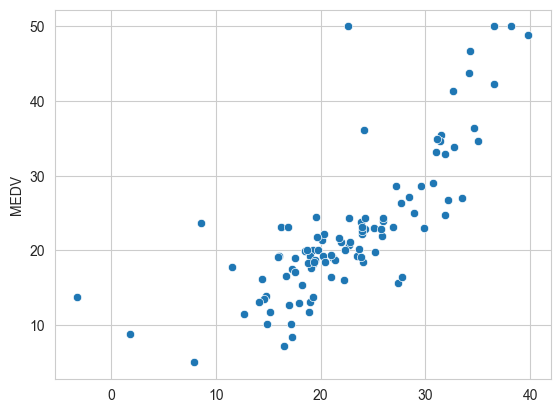

In [97]:
sns.scatterplot(x=pred_test,y=y_test)

<Axes: ylabel='MEDV'>

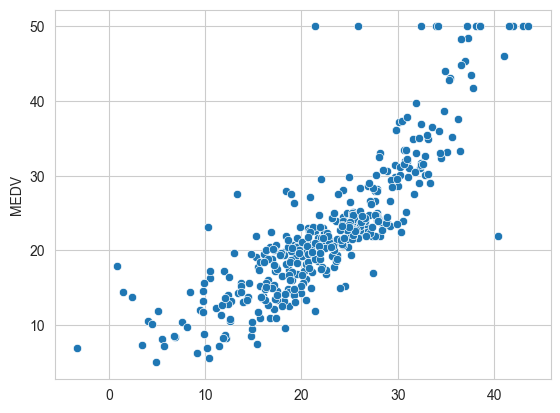

In [98]:
sns.scatterplot(x=pred_train,y=y_train)

In [105]:
from sklearn.linear_model import ElasticNet, Lasso, Ridge

In [155]:
elasticnet = ElasticNet(alpha = 0.2, l1_ratio=0.8)
lasso = Lasso(0.1)
ridge = Ridge(alpha=10)


In [156]:
lasso.fit(x_train_scaled,y_train)
ridge.fit(x_train_scaled,y_train)
elasticnet.fit(x_train_scaled,y_train)

,"alpha alpha: float, default=1.0Constant that multiplies the penalty terms. Defaults to 1.0.See the notes for the exact mathematical meaning of thisparameter. ``alpha = 0`` is equivalent to an ordinary least square,solved by the :class:`LinearRegression` object. For numericalreasons, using ``alpha = 0`` with the ``Lasso`` object is not advised.Given this, you should use the :class:`LinearRegression` object.",0.2
,"l1_ratio l1_ratio: float, default=0.5The ElasticNet mixing parameter, with ``0 <= l1_ratio <= 1``. For``l1_ratio = 0`` the penalty is an L2 penalty. ``For l1_ratio = 1`` itis an L1 penalty. For ``0 < l1_ratio < 1``, the penalty is acombination of L1 and L2.",0.8
,"fit_intercept fit_intercept: bool, default=TrueWhether the intercept should be estimated or not. If ``False``, thedata is assumed to be already centered.",True
,"precompute precompute: bool or array-like of shape (n_features, n_features), default=FalseWhether to use a precomputed Gram matrix to speed upcalculations. The Gram matrix can also be passed as argument.For sparse input this option is always ``False`` to preserve sparsity.Check :ref:`an example on how to use a precomputed Gram Matrix in ElasticNet`for details.",False
,"max_iter max_iter: int, default=1000The maximum number of iterations.",1000
,"copy_X copy_X: bool, default=TrueIf ``True``, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-4The tolerance for the optimization: if the updates are smaller or equal to``tol``, the optimization code checks the dual gap for optimality and continuesuntil it is smaller or equal to ``tol``, see Notes below.",0.0001
,"warm_start warm_start: bool, default=FalseWhen set to ``True``, reuse the solution of the previous call to fit asinitialization, otherwise, just erase the previous solution.See :term:`the Glossary `.",False
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive.",False
,"random_state random_state: int, RandomState instance, default=NoneThe seed of the pseudo random number generator that selects a randomfeature to update. Used when ``selection`` == 'random'.Pass an int for reproducible output across multiple function calls.See :term:`Glossary `.",None
,"selection selection: {'cyclic', 'random'}, default='cyclic'If set to 'random', a random coefficient is updated every iterationrather than looping over features sequentially by default. This(setting to 'random') often leads to significantly faster convergenceespecially when tol is higher than 1e-4.",'cyclic'


In [157]:
pred_train_lasso = lasso.predict(x_train_scaled)
pred_test_lasso = lasso.predict(x_test_scaled)
pred_train_ridge = ridge.predict(x_train_scaled)
pred_test_ridge = ridge.predict(x_test_scaled)
pred_train_elastic = elasticnet.predict(x_train_scaled)
pred_test_elastic = elasticnet.predict(x_test_scaled)

In [158]:
print('MAE train lasso', metrics.mean_absolute_error(y_train, pred_train_lasso))
print('MSE train lasso', metrics.mean_squared_error(y_train, pred_train_lasso))
print('RMSE train lasso', np.sqrt(metrics.mean_squared_error(y_train, pred_train_lasso)))
print('R2 train lasso', lasso.score(x_train_scaled,y_train))
print('MAE test lasso', metrics.mean_absolute_error(y_test, pred_test_lasso))
print('MSE test lasso', metrics.mean_squared_error(y_test, pred_test_lasso))
print('RMSE test lasso', np.sqrt(metrics.mean_squared_error(y_test, pred_test_lasso)))
print('R2 test lasso', lasso.score(x_test_scaled,y_test))

MAE train lasso 3.4451254929989172
MSE train lasso 23.858974531766616
RMSE train lasso 4.884564927582253
R2 train lasso 0.7122267621507905
MAE test lasso 4.1272111849746205
MSE test lasso 35.3919328368367
RMSE test lasso 5.9491119368218905
R2 test lasso 0.6083548752798843


In [159]:
print('MAE train ridge', metrics.mean_absolute_error(y_train, pred_train_ridge))
print('MSE train ridge', metrics.mean_squared_error(y_train, pred_train_ridge))
print('RMSE train ridge', np.sqrt(metrics.mean_squared_error(y_train, pred_train_ridge)))
print('R2 train ridge', ridge.score(x_train_scaled,y_train))
print('MAE test ridge', metrics.mean_absolute_error(y_test, pred_test_ridge))
print('MSE test ridge', metrics.mean_squared_error(y_test, pred_test_ridge))
print('RMSE test ridge', np.sqrt(metrics.mean_squared_error(y_test, pred_test_ridge)))
print('R2 test ridge', ridge.score(x_test_scaled,y_test))

MAE train ridge 3.449703593302986
MSE train ridge 23.776104999545776
RMSE train ridge 4.876074753277043
R2 train ridge 0.7132262868191492
MAE test ridge 4.109900822134109
MSE test ridge 35.330363461169505
RMSE test ridge 5.943935014884458
R2 test ridge 0.6090361985046793


In [160]:
print('MAE train elastic', metrics.mean_absolute_error(y_train, pred_train_elastic))
print('MSE train elastic', metrics.mean_squared_error(y_train, pred_train_elastic))
print('RMSE train elastic', np.sqrt(metrics.mean_squared_error(y_train, pred_train_elastic)))
print('R2 train elastic', elasticnet.score(x_train_scaled,y_train))
print('MAE test elastic', metrics.mean_absolute_error(y_test, pred_test_elastic))
print('MSE test elastic', metrics.mean_squared_error(y_test, pred_test_elastic))
print('RMSE test elastic', np.sqrt(metrics.mean_squared_error(y_test, pred_test_elastic)))
print('R2 test elastic', elasticnet.score(x_test_scaled,y_test))

MAE train elastic 3.4290673221935997
MSE train elastic 24.066025055980788
RMSE train elastic 4.90571351140492
R2 train elastic 0.7097294377300718
MAE test elastic 4.142230540569656
MSE test elastic 35.36252939810611
RMSE test elastic 5.946640177285499
R2 test elastic 0.6086802520679204


In [162]:
# parece que en principio la mejor opcion es el ridge, debe ser que hay mucha colinealidad, y coeficientes muy grandes

In [163]:
# mi conclusión es que he sido demasiado agresivo en la selección de features, probablemente habiendo dejado más de las que estaban originalmente hubiera
# conseguido mejores valores tanto de error como de varianza explicada, lo tendré en cuenta para siguientes ejercicios